In [22]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [2]:
import random

def set_seed(seed=42):
    random.seed(seed)               
    np.random.seed(seed)          
    torch.manual_seed(seed)        
    torch.cuda.manual_seed(seed)    
    torch.cuda.manual_seed_all(seed)  
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False  

当前计算设备: cuda
开始训练模型 (3 Epochs)...
Epoch 1 完成, Loss: 0.2215
Epoch 2 完成, Loss: 0.3079
Epoch 3 完成, Loss: 0.1371
Epoch 4 完成, Loss: 0.0827
Epoch 5 完成, Loss: 0.1530
Epoch 6 完成, Loss: 0.0607
Epoch 7 完成, Loss: 0.0454
Epoch 8 完成, Loss: 0.0418
Epoch 9 完成, Loss: 0.0991
Epoch 10 完成, Loss: 0.0129
Epoch 11 完成, Loss: 0.0065
Epoch 12 完成, Loss: 0.0109
Epoch 13 完成, Loss: 0.0544
Epoch 14 完成, Loss: 0.0524
Epoch 15 完成, Loss: 0.0083
开始计算期望雅可比矩阵...

--- 相邻层分析 (H1 -> H2) ---


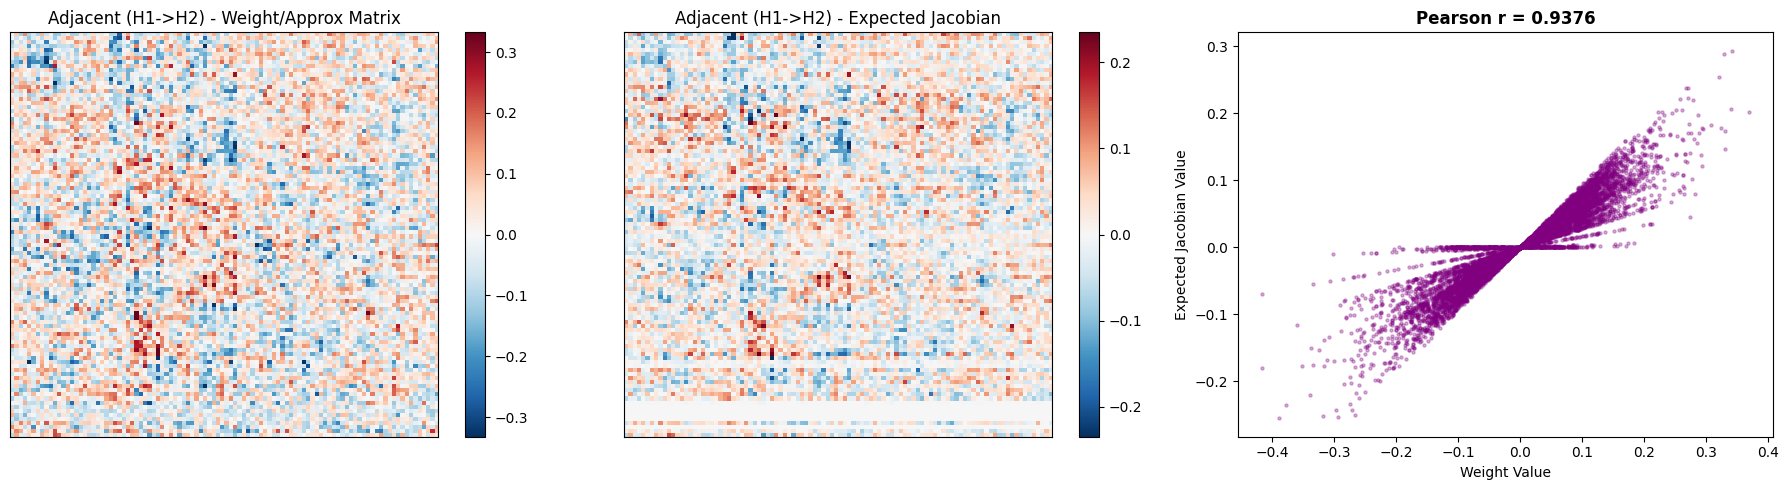


--- 跨层分析 (H1 -> H3) ---


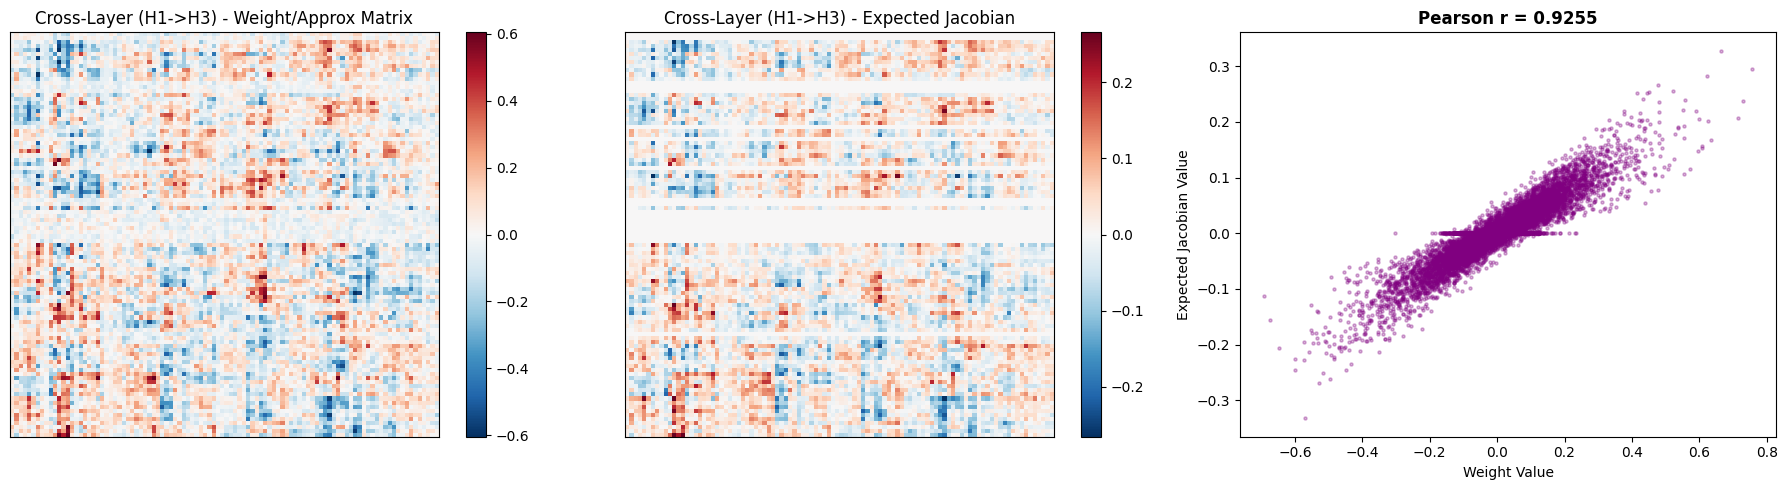

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.func import vmap, jacrev
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import warnings

# 忽略聚类时极小方差可能产生的警告
warnings.filterwarnings('ignore')

# ==========================================
# 1. 设备与数据准备
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前计算设备: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
# 为了雅可比矩阵计算，选取 500 个测试样本来计算期望
test_loader = DataLoader(test_dataset, batch_size=500, shuffle=True) 

# ==========================================
# 2. 构建 MLP [784, 100, 100, 100, 10]
# ==========================================
class DeepMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 100)
        self.fc2 = nn.Linear(100, 100)
        self.fc3 = nn.Linear(100, 100)
        self.fc4 = nn.Linear(100, 10)
        self.act = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 784)
        h1 = self.act(self.fc1(x))
        h2 = self.act(self.fc2(h1))
        h3 = self.act(self.fc3(h2))
        out = self.fc4(h3)
        return out

    def get_hidden_activations(self, x):
        """一次性返回前三个隐藏层的激活值"""
        x = x.view(-1, 784)
        h1 = self.act(self.fc1(x))
        h2 = self.act(self.fc2(h1))
        h3 = self.act(self.fc3(h2))
        return h1, h2, h3
set_seed(42)
model = DeepMLP().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# ==========================================
# 3. 训练网络
# ==========================================
print("开始训练模型 (3 Epochs)...")
model.train()
for epoch in range(15):
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} 完成, Loss: {loss.item():.4f}")

# ==========================================
# 4. 提取权重与获取 H1 激活分布
# ==========================================
model.eval()

W2 = model.fc2.weight.detach()
b2 = model.fc2.bias.detach()
W3 = model.fc3.weight.detach()
b3 = model.fc3.bias.detach()
act_fn = model.act

# 获取一批测试数据以计算 H1 的真实分布
X_test, _ = next(iter(test_loader))
X_test = X_test.to(device)
with torch.no_grad():
    H1_samples = act_fn(model.fc1(X_test.view(-1, 784))) # [500, 100]

# ==========================================
# 5. 定义前向截断函数并计算雅可比矩阵
# ==========================================
print("开始计算期望雅可比矩阵...")

# 5.1 纯函数：H1 -> H2
def step_1_to_2(h1):
    return act_fn(F.linear(h1, W2, b2))

# 5.2 纯函数：H1 -> H3
def step_1_to_3(h1):
    h2 = act_fn(F.linear(h1, W2, b2))
    return act_fn(F.linear(h2, W3, b3))

# 计算雅可比矩阵 (vmap 在 batch 维度并行求导)
jac_fn_1_2 = vmap(jacrev(step_1_to_2))
jac_fn_1_3 = vmap(jacrev(step_1_to_3))

# 一次性计算所有样本并求均值得到期望
J_1_2_expected = jac_fn_1_2(H1_samples).mean(dim=0).cpu().numpy()
J_1_3_expected = jac_fn_1_3(H1_samples).mean(dim=0).cpu().numpy()

# 计算跨层近似权重矩阵 W3 * W2
W_1_to_3_approx = torch.mm(W3, W2).cpu().numpy()

# 转回 CPU numpy 以备聚类和绘图
W2_np = W2.cpu().numpy()

# ==========================================
# 6. 定义通用可视化与聚类函数
# ==========================================
def plot_analysis(W_matrix, J_matrix, title_prefix):
    # 计算展平后的 Pearson 相关系数
    w_flat = W_matrix.flatten()
    j_flat = J_matrix.flatten()
    correlation = np.corrcoef(w_flat, j_flat)[0, 1]
    
    # 基于 W_matrix 计算行和列的层次聚类顺序
    # 使用 cosine 距离和 ward 方法
    row_dist = pdist(W_matrix, metric='cosine')
    col_dist = pdist(W_matrix.T, metric='cosine')
    
    row_order = sch.leaves_list(sch.linkage(row_dist, method='ward'))
    col_order = sch.leaves_list(sch.linkage(col_dist, method='ward'))
    
    # 按照 W_matrix 产生的聚类顺序，同时重排 W 和 J
    W_clustered = W_matrix[row_order, :][:, col_order]
    J_clustered = J_matrix[row_order, :][:, col_order]
    
    # 绘图
    fig = plt.figure(figsize=(18, 5))
    
    # 子图1: 聚类后的权重热图
    ax1 = fig.add_subplot(1, 3, 1)
    vmax = np.max(np.abs(W_clustered)) * 0.8
    im1 = ax1.imshow(W_clustered, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
    ax1.set_title(f"{title_prefix} - Weight/Approx Matrix")
    ax1.set_xticks([])
    ax1.set_yticks([])
    plt.colorbar(im1, ax=ax1)
    
    # 子图2: 聚类后的雅可比热图
    ax2 = fig.add_subplot(1, 3, 2)
    vmax_j = np.max(np.abs(J_clustered)) * 0.8
    im2 = ax2.imshow(J_clustered, cmap='RdBu_r', aspect='auto', vmin=-vmax_j, vmax=vmax_j)
    ax2.set_title(f"{title_prefix} - Expected Jacobian")
    ax2.set_xticks([])
    ax2.set_yticks([])
    plt.colorbar(im2, ax=ax2)
    
    # 子图3: 相关性散点图
    ax3 = fig.add_subplot(1, 3, 3)
    # 随机采样以防止点过密导致渲染缓慢
    idx = np.random.choice(len(w_flat), min(10000, len(w_flat)), replace=False)
    ax3.scatter(w_flat[idx], j_flat[idx], alpha=0.3, s=5, color='purple')
    ax3.set_title(f"Pearson r = {correlation:.4f}", fontweight='bold')
    ax3.set_xlabel("Weight Value")
    ax3.set_ylabel("Expected Jacobian Value")
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 7. 执行分析并绘图
# ==========================================
print("\n--- 相邻层分析 (H1 -> H2) ---")
plot_analysis(W2_np, J_1_2_expected, "Adjacent (H1->H2)")

print("\n--- 跨层分析 (H1 -> H3) ---")
plot_analysis(W_1_to_3_approx, J_1_3_expected, "Cross-Layer (H1->H3)")

正在提取激活数据与权重...
正在计算期望雅可比矩阵...
正在计算跨层功能连接 (Cross-Layer FC)...

生成 H1 -> H2 分析图表...


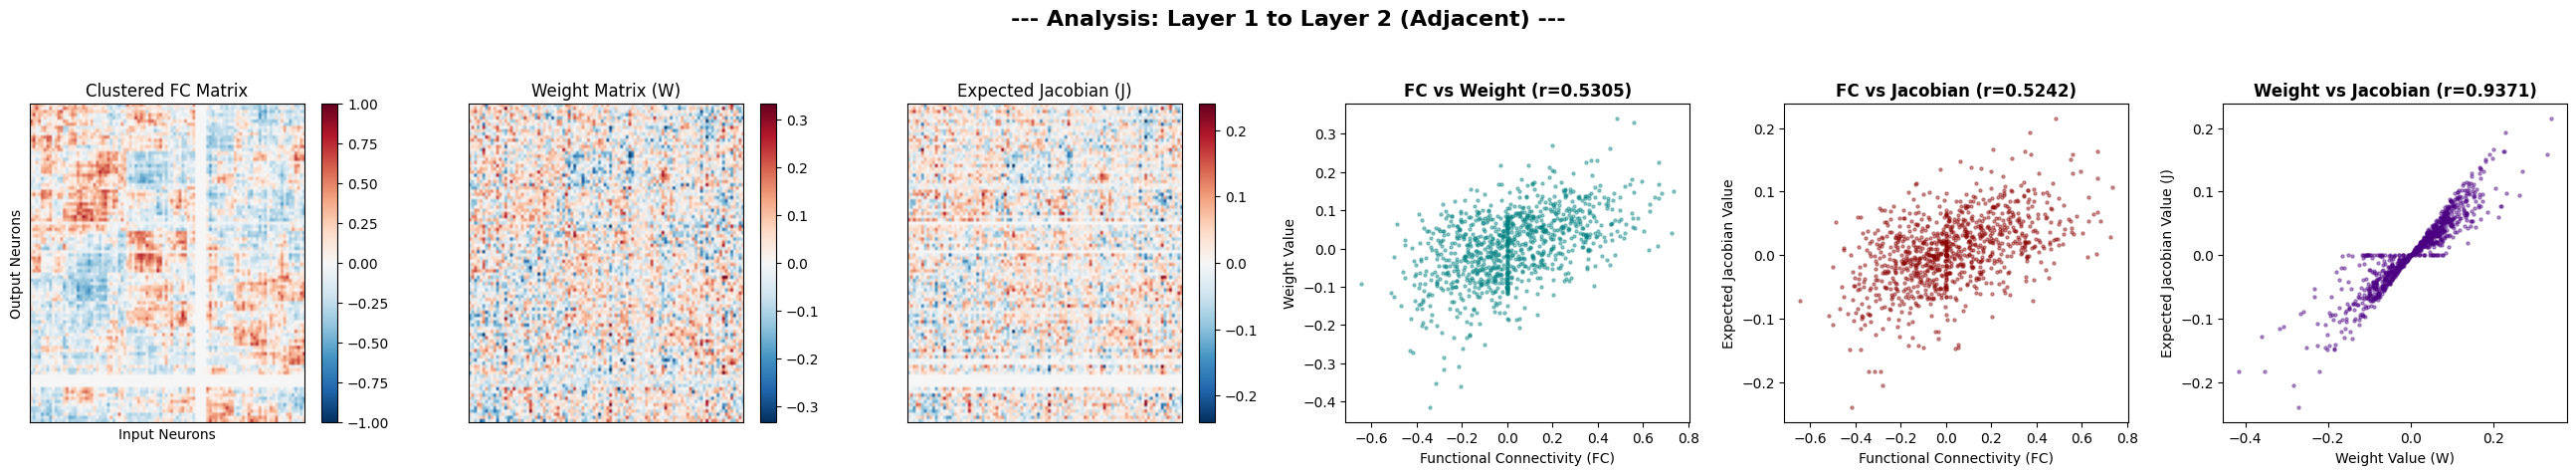


生成 H1 -> H3 分析图表...


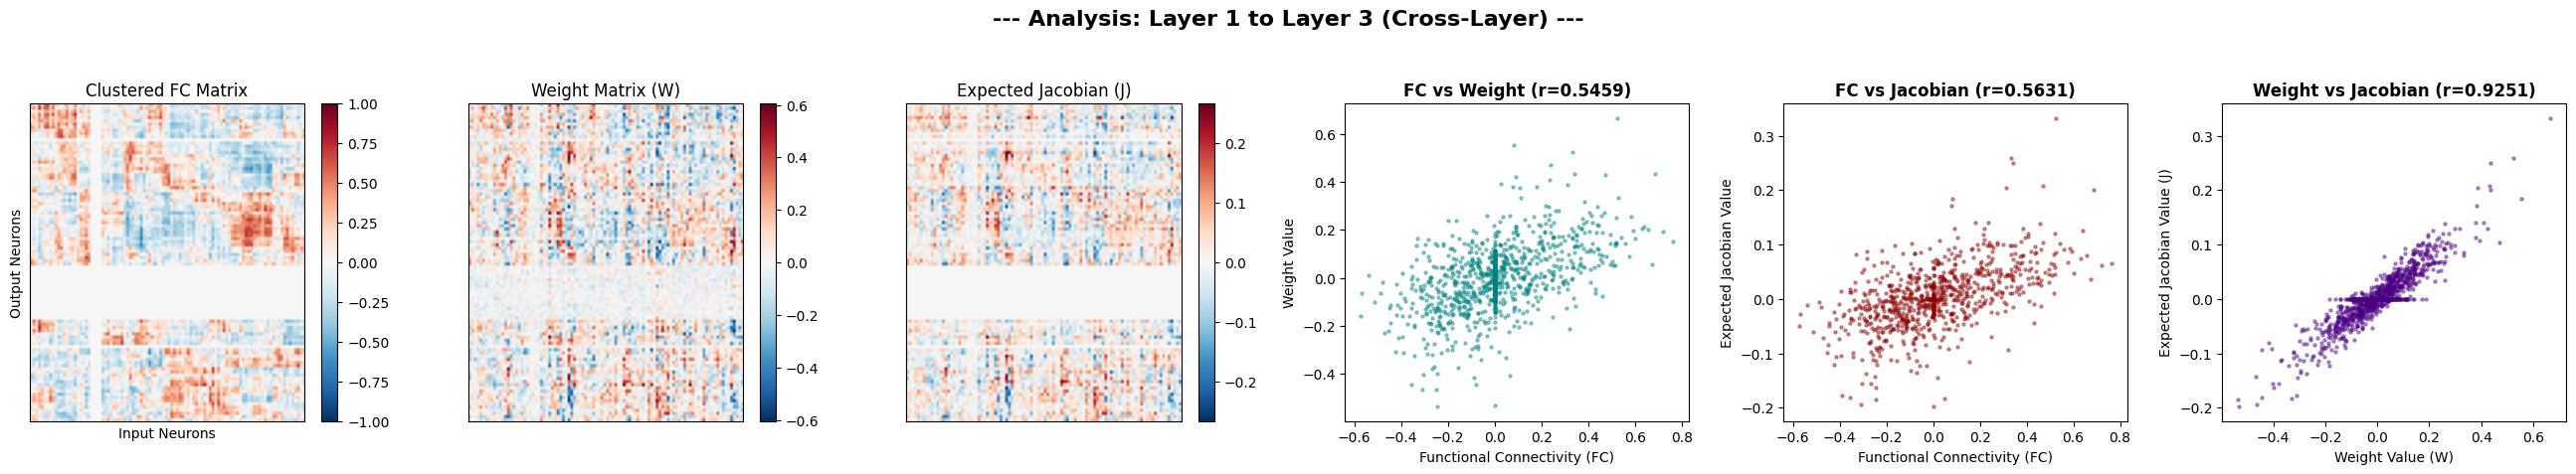

In [26]:
import torch
import torch.nn.functional as F
from torch.func import vmap, jacrev
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import warnings

# 忽略聚类过程中的计算警告
warnings.filterwarnings('ignore')

def calculate_cross_layer_fc(H_in, H_out):
    """
    计算跨层功能连接 (Cross-Layer Functional Connectivity)
    H_in: [N_samples, D_in] (例如 H1)
    H_out: [N_samples, D_out] (例如 H2 或 H3)
    返回矩阵形状: [D_out, D_in]
    """
    # 样本维度去中心化
    H_in_centered = H_in - np.mean(H_in, axis=0)
    H_out_centered = H_out - np.mean(H_out, axis=0)
    
    # 计算标准差 (加入极小值防止除以0)
    H_in_std = np.std(H_in, axis=0) + 1e-8
    H_out_std = np.std(H_out, axis=0) + 1e-8
    
    # 标准化
    H_in_norm = H_in_centered / H_in_std
    H_out_norm = H_out_centered / H_out_std
    
    # 计算交叉相关矩阵，结果形状 [D_out, D_in]
    N = H_in.shape[0]
    FC_cross = np.dot(H_out_norm.T, H_in_norm) / N
    return np.nan_to_num(FC_cross)


# def calculate_cross_layer_fc(H_in, H_out):
#     """
#     计算跨层功能连接 (使用斯皮尔曼秩相关系数)
#     """
#     # 1. 将原始激活值转换为秩次 (Rank)
#     # 对于连续的激活值，连续两次 argsort 可以极速获得每个样本在当前 Batch 中的相对排名
#     # axis=0 表示在样本维度上进行排名
#     H_in_rank = np.argsort(np.argsort(H_in, axis=0), axis=0)
#     H_out_rank = np.argsort(np.argsort(H_out, axis=0), axis=0)
    
#     # 2. 以下步骤与皮尔逊计算完全一致，只是输入变成了秩次矩阵
#     # 样本维度去中心化
#     H_in_centered = H_in_rank - np.mean(H_in_rank, axis=0)
#     H_out_centered = H_out_rank - np.mean(H_out_rank, axis=0)
    
#     # 计算标准差 (加入极小值防止除以0)
#     H_in_std = np.std(H_in_rank, axis=0) + 1e-8
#     H_out_std = np.std(H_out_rank, axis=0) + 1e-8
    
#     # 标准化
#     H_in_norm = H_in_centered / H_in_std
#     H_out_norm = H_out_centered / H_out_std
    
#     # 计算交叉相关矩阵，结果形状 [D_out, D_in]
#     N = H_in.shape[0]
#     FC_cross_spearman = np.dot(H_out_norm.T, H_in_norm) / N
    
#     return np.nan_to_num(FC_cross_spearman)

def plot_five_panels(FC, W, J, title_prefix):
    """
    基于 FC 的聚类顺序，绘制 5 个图表 (3个热图 + 2个散点图)
    """
    # 1. 展平以便计算相关性和绘制散点图
    fc_flat = FC.flatten()
    w_flat = W.flatten()
    j_flat = J.flatten()
    
    corr_w_fc = np.corrcoef(w_flat, fc_flat)[0, 1]
    corr_j_fc = np.corrcoef(j_flat, fc_flat)[0, 1]
    
    # 2. 基于 FC 进行双向聚类 (Biclustering)
    # 因为 FC 不是对称矩阵，我们需要分别对行(输出神经元)和列(输入神经元)聚类
    # row_dist = pdist(FC, metric='cosine')
    # col_dist = pdist(FC.T, metric='cosine')
    row_dist = pdist(FC, metric='cosine')
    row_dist = np.nan_to_num(row_dist, nan=1.0)
    
    col_dist = pdist(FC.T, metric='cosine')
    col_dist = np.nan_to_num(col_dist, nan=1.0)
    
    row_order = sch.leaves_list(sch.linkage(row_dist, method='ward'))
    col_order = sch.leaves_list(sch.linkage(col_dist, method='ward'))
    
    # 按照相同的顺序重排三个矩阵
    FC_c = FC[row_order, :][:, col_order]
    W_c = W[row_order, :][:, col_order]
    J_c = J[row_order, :][:, col_order]
    
    # 1. 计算额外的相关系数 (W vs J)
    corr_w_j = np.corrcoef(w_flat, j_flat)[0, 1]

    # 3. 绘图 (修改为 1x6 布局，加宽画布)
    fig = plt.figure(figsize=(26, 4.5))
    
    # 热图 1: 功能连接 FC
    ax1 = fig.add_subplot(1, 6, 1)
    im1 = ax1.imshow(FC_c, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    ax1.set_title(f"Clustered FC Matrix")
    ax1.set_ylabel("Output Neurons")
    ax1.set_xlabel("Input Neurons")
    ax1.set_xticks([])
    ax1.set_yticks([])
    plt.colorbar(im1, ax=ax1)
    
    # 热图 2: 真实/近似权重 W
    ax2 = fig.add_subplot(1, 6, 2)
    vmax_w = np.max(np.abs(W_c)) * 0.8
    im2 = ax2.imshow(W_c, cmap='RdBu_r', aspect='auto', vmin=-vmax_w, vmax=vmax_w)
    ax2.set_title(f"Weight Matrix (W)")
    ax2.set_xticks([])
    ax2.set_yticks([])
    plt.colorbar(im2, ax=ax2)
    
    # 热图 3: 期望雅可比 J
    ax3 = fig.add_subplot(1, 6, 3)
    vmax_j = np.max(np.abs(J_c)) * 0.8
    im3 = ax3.imshow(J_c, cmap='RdBu_r', aspect='auto', vmin=-vmax_j, vmax=vmax_j)
    ax3.set_title(f"Expected Jacobian (J)")
    ax3.set_xticks([])
    ax3.set_yticks([])
    plt.colorbar(im3, ax=ax3)

    # 设定抽样数量，例如随机抽取 2000 个点
    sample_size = min(1000, len(fc_flat))
    # 无放回地随机生成索引
    idx = np.random.choice(len(fc_flat), sample_size, replace=False)
    
    # 散点图 1: W vs FC
    ax4 = fig.add_subplot(1, 6, 4)
    ax4.scatter(fc_flat[idx], w_flat[idx], alpha=0.4, s=5, color='teal')
    ax4.set_title(f"FC vs Weight (r={corr_w_fc:.4f})", fontweight='bold')
    ax4.set_xlabel("Functional Connectivity (FC)")
    ax4.set_ylabel("Weight Value")
    
    # 散点图 2: J vs FC
    ax5 = fig.add_subplot(1, 6, 5)
    ax5.scatter(fc_flat[idx], j_flat[idx], alpha=0.4, s=5, color='darkred')
    ax5.set_title(f"FC vs Jacobian (r={corr_j_fc:.4f})", fontweight='bold')
    ax5.set_xlabel("Functional Connectivity (FC)")
    ax5.set_ylabel("Expected Jacobian Value")

    # 散点图 3: W vs J (新增)
    ax6 = fig.add_subplot(1, 6, 6)
    ax6.scatter(w_flat[idx], j_flat[idx], alpha=0.4, s=5, color='indigo')
    ax6.set_title(f"Weight vs Jacobian (r={corr_w_j:.4f})", fontweight='bold')
    ax6.set_xlabel("Weight Value (W)")
    ax6.set_ylabel("Expected Jacobian Value (J)")
    
    fig.suptitle(f"--- Analysis: {title_prefix} ---", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(f'./fig/{title_prefix.replace(" ", "_")}_analysis.pdf', format='pdf')
    plt.show()

def analyze_fc_vs_weights_jacobians(model, data_loader):
    """
    主控制函数：提取数据、计算矩阵并调用绘图
    """
    device = next(model.parameters()).device
    model.eval()
    
    H1_list, H2_list, H3_list = [], [], []
    
    # 1. 采集激活数据 (收集约 2000 个样本用于稳定估计)
    print("正在提取激活数据与权重...")
    with torch.no_grad():
        for i, (data, _) in enumerate(data_loader):
            data = data.to(device)
            h1, h2, h3 = model.get_hidden_activations(data)
            H1_list.append(h1)
            H2_list.append(h2)
            H3_list.append(h3)
            if i >= 7: # 约 2000 个样本 (8个 batch)
                break
                
    H1_tensor = torch.cat(H1_list, dim=0)
    
    H1_np = H1_tensor.cpu().numpy()
    H2_np = torch.cat(H2_list, dim=0).cpu().numpy()
    H3_np = torch.cat(H3_list, dim=0).cpu().numpy()
    
    # 2. 提取并计算权重矩阵
    W2 = model.fc2.weight.detach()
    b2 = model.fc2.bias.detach()
    W3 = model.fc3.weight.detach()
    b3 = model.fc3.bias.detach()
    
    W2_np = W2.cpu().numpy()
    W_1_to_3_approx = torch.mm(W3, W2).cpu().numpy()
    
    # 3. 计算期望雅可比矩阵
    print("正在计算期望雅可比矩阵...")
    act_fn = model.act
    
    def step_1_to_2(x): return act_fn(F.linear(x, W2, b2))
    def step_1_to_3(x): return act_fn(F.linear(act_fn(F.linear(x, W2, b2)), W3, b3))
    
    jac_fn_1_2 = vmap(jacrev(step_1_to_2))
    jac_fn_1_3 = vmap(jacrev(step_1_to_3))
    
    # 使用 500 个样本计算期望以节约内存
    sample_tensor = H1_tensor[:500]
    J_1_2_expected = jac_fn_1_2(sample_tensor).mean(dim=0).cpu().numpy()
    J_1_3_expected = jac_fn_1_3(sample_tensor).mean(dim=0).cpu().numpy()
    
    # 4. 计算跨层功能连接 FC
    print("正在计算跨层功能连接 (Cross-Layer FC)...")
    FC_1_to_2 = calculate_cross_layer_fc(H1_np, H2_np)
    FC_1_to_3 = calculate_cross_layer_fc(H1_np, H3_np)
    
    # 5. 执行分析并绘图
    print("\n生成 H1 -> H2 分析图表...")
    plot_five_panels(FC_1_to_2, W2_np, J_1_2_expected, "Layer 1 to Layer 2 (Adjacent)")
    
    print("\n生成 H1 -> H3 分析图表...")
    plot_five_panels(FC_1_to_3, W_1_to_3_approx, J_1_3_expected, "Layer 1 to Layer 3 (Cross-Layer)")

# ==========================================
# 执行函数
# ==========================================
# 假设前文的 model 和 test_loader 已经在内存中准备就绪

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
analyze_fc_vs_weights_jacobians(model, train_loader)